In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

from ethos.constants import PROJECT_ROOT, ADMISSION_STOKEN, DISCHARGE_STOKEN, ICU_ADMISSION_STOKEN, PROJECT_DATA, \
    ICU_DISCHARGE_STOKEN
from ethos.metrics import process_readmission_results, compute_gaussian_metrics, \
    process_admission_results

readmission_period = 30 / 365.25

In [27]:
def process_benchmark_readmission_results(
        folder_name: str, admission_stoken: str, readmission_period: float, suffix: str
) -> pd.DataFrame:
    res_dir = PROJECT_ROOT / "results_benchmark" / folder_name
    # Filter files by suffix (e.g., 'kv_off' or 'kv_on_and_cut')
    res_paths = [p for p in res_dir.iterdir() if suffix in p.name and p.suffix == ".json"]
    
    if not res_paths:
        raise ValueError(f"No files found with suffix '{suffix}' in {res_dir}")
        
    df = pd.concat(pd.read_json(res_path) for res_path in res_paths)
    df.rename(columns={"actual": "actual_token", "patient_id": "subject_id"}, inplace=True)
    df["actual"] = (df.actual_token == admission_stoken).astype(int)
    df["expected"] = ((df.expected == 1) & (df.true_token_time <= readmission_period)).astype(int)
    discharge_idx_name = (
        "discharge_token_idx" if admission_stoken == ADMISSION_STOKEN else "discharge_idx"
    )
    df_gb = df.groupby(discharge_idx_name, dropna=False)
    return (
        df_gb.agg(
            {
                "subject_id": "first",
                "expected": "first",
                "actual": "mean",
                "true_token_time": "first",
                "true_token_dist": "first",
                "token_time": "mean",
                "token_dist": "mean",
                "patient_age": "first",
                discharge_idx_name: "first",
            }
        )
        .join(df_gb.agg(count=("actual", "count")))
        .reset_index(drop=True)
        .set_index("subject_id")
    )

In [28]:
folder_name = "icu_readmission_ethos_official_test"
folder_name_g = "icu_readmission_mimic_layer_6_batch_32_do_0.3_best_test"
df_kv_off = process_benchmark_readmission_results(folder_name, ICU_ADMISSION_STOKEN, readmission_period, "")
df_kv_cut = process_benchmark_readmission_results(folder_name, ICU_ADMISSION_STOKEN, readmission_period, "kv_on_and_cut")
df_kv_int8 = process_benchmark_readmission_results(folder_name, ICU_ADMISSION_STOKEN, readmission_period, "kv_on_int8")
df_kv_fp16 = process_benchmark_readmission_results(folder_name, ICU_ADMISSION_STOKEN, readmission_period, "kv_on_fp16")

In [29]:
from matplotlib.offsetbox import AnchoredText
import numpy as np

black_color = "#404040ff"
gray_color = "#b2b2b2ff"
orange_color = "#1f77b4ff"
font_size = 18

sns.set(context="paper", style="white")

plt.rcParams['font.family'] = 'Roboto'
plt.rcParams['axes.labelcolor'] = black_color
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlecolor'] = black_color
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.color'] = black_color
plt.rcParams['xtick.color'] = black_color
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.color'] = black_color
plt.rcParams['ytick.labelsize'] = font_size
plt.rcParams['axes.titlesize'] = font_size


def compute_ci(y_true, y_proba, n_bootstraps=1000, seed=42, auprc=False) -> list:
    import numpy as np
    np.random.seed(seed)
    aucs = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    score_name = "auprc" if auprc else "auc"
    x_name = ("recall" if auprc else "fpr") + "_values"
    y_name = ("precision" if auprc else "tpr") + "_values"

    for _ in range(n_bootstraps):
        indices = np.random.choice(len(y_true), len(y_true), replace=True)
        y_true_boot = y_true.values[indices]
        y_proba_boot = y_proba.values[indices]
        res = compute_gaussian_metrics(y_true_boot, y_proba_boot)
        aucs.append(res[score_name])
        tprs.append(np.interp(mean_fpr, res[x_name], res[y_name]))
        tprs[-1][0] = 0.0
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0  # Ensure ending at 1
    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    return np.percentile(aucs, [2.5, 97.5]), mean_fpr, tprs_lower, tprs_upper


def plot_auc(y_true, y_proba, title="AUC-ROC", auprc=False, existing_study=None):
    res_fit = compute_gaussian_metrics(y_true, y_proba)

    if not auprc:
        (ci_lower, ci_upper), mean_fpr, tprs_lower, tprs_upper = compute_ci(y_true, y_proba,
                                                                            auprc=auprc)
        plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=gray_color, alpha=0.4,
                         label="95% Confidence Interval")

        plt.scatter(res_fit["fpr_points"], res_fit["tpr_points"],
                    marker="X", color=black_color, s=100,
                    label="Unique Thresholds")

    score_name = "auprc" if auprc else "auc"
    x_name = ("recall" if auprc else "fpr") + "_values"
    y_name = ("precision" if auprc else "tpr") + "_values"

    
    plt.plot(
        res_fit[x_name],
        res_fit[y_name],
        color=orange_color,
        lw=5,
        label="Fitted ROC curve",
    )
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.title(title)
    plt.grid(False)

    text = [f"Gaussian " + ("PR-" if auprc else "") + f"AUC: {res_fit[score_name]:.3f}"]
    
    if not auprc:
        text.append(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
        text.append(f"Gaussian PR-AUC: {res_fit['auprc']:.3f}")
        
    text.append(f"N: {len(y_true):,} ({y_true.mean():.1%} positives)")

    at = AnchoredText(
        "\n".join(text),
        loc="upper right" if auprc else "lower right",
        frameon=False,
        prop=dict(size=font_size, color=black_color),
    )
    plt.gca().add_artist(at)

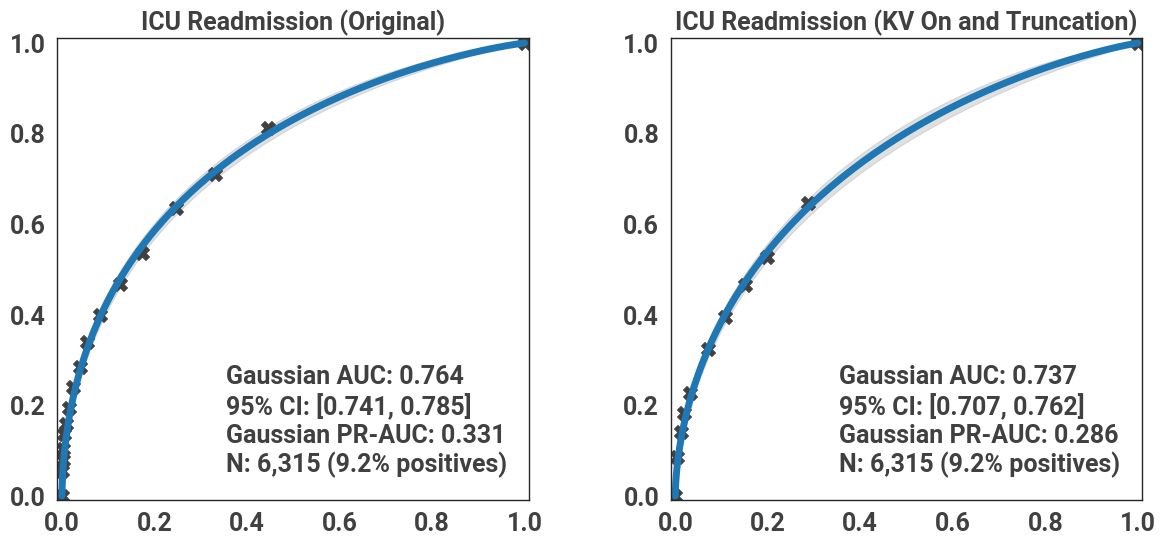

In [35]:
result_groups = [
    ("ICU Readmission (Original)", df_kv_off, 0.820),
    ("ICU Readmission (KV On and Truncation)", df_kv_cut, 0.820)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (title, df, existing_study) in enumerate(result_groups):
    ax: plt.Axes = axes[i]
    plt.sca(ax)
    if df is None:
        ax.set_visible(False)
        continue

    plot_auc(df.expected, df.actual, title=title, existing_study=existing_study)
    if i == 3:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels[::-1], loc="center right", frameon=False,
                  fontsize=font_size, bbox_to_anchor=(1.0, 0.5))

fig.subplots_adjust(wspace=0.3)